# REG Architecture & Building

## Research context

Architecture & Building (CategoryKey = 4) sits in the **control group** of the full cross-category DiD — it was not a JRG priority field — but its students and funding still shifted after the 2021 package:

| Period | Student contribution (avg) | Commonwealth contribution (avg) |
|--------|---------------------------|----------------------------------|
| 2019   | $9,359                     | $10,630                          |
| 2021+  | $7,950 (−15 %)             | $13,250 (+25 %)                  |

Despite these favourable funding changes, AUS Architecture & Building enrolments **plateaued and then declined** from 2022 onward while the UK counterpart kept growing. This notebook estimates whether that divergence is statistically attributable to the JRG policy.

### Identifying strategy (country-level DiD)

$$\log(\text{Enrolments}_{ct}) = \alpha_c + \gamma_t + \beta(\text{AUS}_c \times \text{Post}_t) + \delta_1(\text{AUS}_c \times \text{COVID2020}_t) + \delta_2(\text{AUS}_c \times \text{COVID2021}_t) + \varepsilon_{ct}$$

where $c \in \{\text{AUS, UK}\}$, $\text{Post}_t = \mathbf{1}[t \geq 2021]$, and $\beta$ is the main JRG effect for this field.

**Data window:** AUS 2016–2024 (9 years); UK 2016–2024 (9 years, start-year mapping: 2016/17 → 2016).
Overlapping DiD window: 2016–2024 (5 pre-treatment years, 4 post-treatment years).

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from linearmodels.panel import PanelOLS
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

START = Path.cwd()
ROOT = START
while ROOT != ROOT.parent and not (ROOT / "data").exists():
    ROOT = ROOT.parent

AUS_PATH  = ROOT / "data" / "clean" / "EnrollmentsAUS_category_with_numeric_key.csv"
UK_PATH   = ROOT / "data" / "clean" / "uk_grouped" / "with_categorykey" / "UK_enrollments_grouped_comparison_all_years_with_categorykey.csv"
FUND_PATH = ROOT / "data" / "clean" / "AnnualFundingAUS2019-2026_with_category_key.csv"

assert AUS_PATH.exists(),  f"Missing: {AUS_PATH}"
assert UK_PATH.exists(),   f"Missing: {UK_PATH}"
assert FUND_PATH.exists(), f"Missing: {FUND_PATH}"
print("Project root:", ROOT)
print("All data files found.")

Project root: C:\Users\neddp\ECC3479-Project-JRGS
All data files found.


## 1. AUS Descriptive Analysis

Before fitting the DiD, examine Australia-only data (2016–2024) to characterise the enrolment trend and test a simple pre/post break.
AUS-only OLS is log-linear with HC3 robust SEs, as per Lecture 6 conventions.

AUS Architecture & Building — enrolment data:


,year,enrollments,log_enrollments
0,2016,32074,10.375801
1,2017,35604,10.480213
2,2018,39459,10.583017
3,2019,42370,10.654196
4,2020,43478,10.680010
5,2021,43773,10.686772
6,2022,42327,10.653180
7,2023,42174,10.649559
8,2024,40942,10.619912


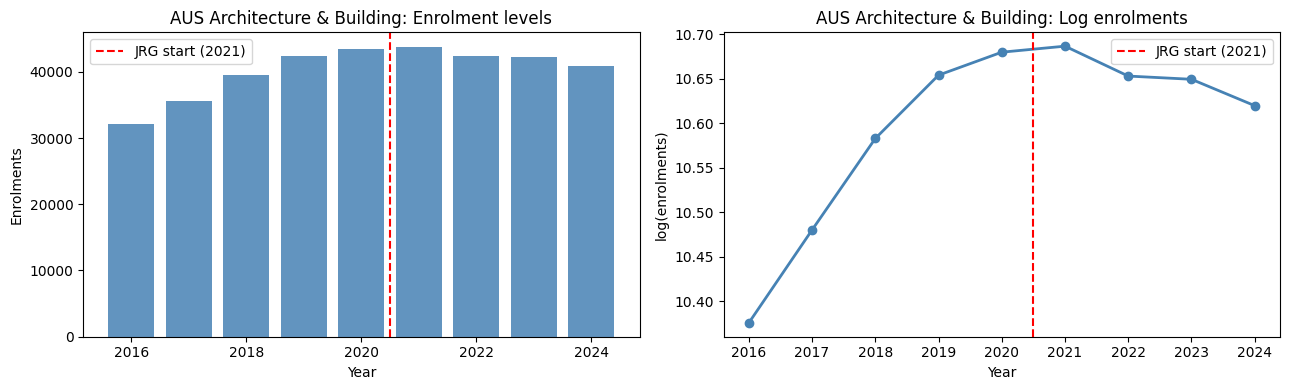

In [2]:
aus_raw   = pd.read_csv(AUS_PATH)
year_cols = [c for c in aus_raw.columns if str(c).isdigit()]

aus_long = aus_raw.melt(
    id_vars=["Category", "CategoryKey"],
    value_vars=year_cols,
    var_name="year",
    value_name="enrollments",
)
aus_long["year"]        = aus_long["year"].astype(int)
aus_long["enrollments"] = pd.to_numeric(aus_long["enrollments"], errors="coerce")

arch_aus = aus_long[aus_long["CategoryKey"] == 4].copy().sort_values("year").reset_index(drop=True)
arch_aus["log_enrollments"] = np.log(arch_aus["enrollments"])
arch_aus["year_c"]   = arch_aus["year"] - 2019
arch_aus["year_c2"]  = arch_aus["year_c"] ** 2
arch_aus["post_jrg"] = (arch_aus["year"] >= 2021).astype(int)

print("AUS Architecture & Building — enrolment data:")
display(arch_aus[["year", "enrollments", "log_enrollments"]].reset_index(drop=True))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(arch_aus["year"], arch_aus["enrollments"], color="steelblue", alpha=0.85)
axes[0].axvline(2020.5, linestyle="--", color="red", linewidth=1.5, label="JRG start (2021)")
axes[0].set_title("AUS Architecture & Building: Enrolment levels")
axes[0].set_xlabel("Year"); axes[0].set_ylabel("Enrolments"); axes[0].legend()

axes[1].plot(arch_aus["year"], arch_aus["log_enrollments"], "o-", color="steelblue", linewidth=2)
axes[1].axvline(2020.5, linestyle="--", color="red", linewidth=1.5, label="JRG start (2021)")
axes[1].set_title("AUS Architecture & Building: Log enrolments")
axes[1].set_xlabel("Year"); axes[1].set_ylabel("log(enrolments)"); axes[1].legend()

plt.tight_layout()
plt.show()

In [3]:
def summary_table(result, vars_):
    ci = result.conf_int()
    rows = []
    for v in vars_:
        if v not in result.params.index:
            continue
        rows.append({
            "Variable": v,
            "beta":     round(result.params[v], 4),
            "SE (HC3)": round(result.bse[v], 4),
            "p":        round(result.pvalues[v], 4),
            "CI lo":    round(ci.loc[v, 0], 4),
            "CI hi":    round(ci.loc[v, 1], 4),
        })
    out = pd.DataFrame(rows).set_index("Variable")
    display(out)
    print(f"R² = {result.rsquared:.4f} | Adj. R² = {result.rsquared_adj:.4f} | N = {int(result.nobs)}")

m_linear = smf.ols("log_enrollments ~ post_jrg + year_c",           data=arch_aus).fit(cov_type="HC3")
m_quad   = smf.ols("log_enrollments ~ post_jrg + year_c + year_c2", data=arch_aus).fit(cov_type="HC3")

print("=== AUS-only OLS: linear time trend ===")
summary_table(m_linear, ["Intercept", "post_jrg", "year_c"])
b_aus = m_linear.params["post_jrg"]
print(f"\npost_jrg: ~{b_aus*100:.2f}% change in AUS enrolments post-JRG (after controlling for linear trend)")

print("\n=== AUS-only OLS: quadratic time trend ===")
summary_table(m_quad, ["Intercept", "post_jrg", "year_c", "year_c2"])

=== AUS-only OLS: linear time trend ===


,beta,SE (HC3),p,CI lo,CI hi
Variable,,,,,
Intercept,10.6000,0.0404,0.0000,10.5208,10.6792
post_jrg,-0.1064,0.1552,0.4931,-0.4106,0.1978
year_c,0.0454,0.0342,0.1842,-0.0216,0.1123


R² = 0.5956 | Adj. R² = 0.4608 | N = 9

post_jrg: ~-10.64% change in AUS enrolments post-JRG (after controlling for linear trend)

=== AUS-only OLS: quadratic time trend ===


,beta,SE (HC3),p,CI lo,CI hi
Variable,,,,,
Intercept,10.6437,0.0093,0.0000,10.6255,10.6619
post_jrg,-0.0409,0.0428,0.3396,-0.1248,0.0430
year_c,0.0563,0.0049,0.0000,0.0467,0.0658
year_c2,-0.0109,0.0017,0.0000,-0.0143,-0.0075


R² = 0.9884 | Adj. R² = 0.9815 | N = 9


## 2. DiD Panel Construction

Combine AUS and UK Architecture & Building data into a country × year panel for the overlapping window (2019–2024).

**UK year mapping:** start-year rule — `2019/20 → 2019`, `2020/21 → 2020`, etc.

**Treatment indicators:**
- `treated = 1` for AUS, `0` for UK
- `post = 1` for 2021+
- `did = treated × post` (main DiD interaction)
- `treated_covid2020`, `treated_covid2021` — AUS-specific COVID shock controls (deviation from common year effect)

In [4]:
uk_raw  = pd.read_csv(UK_PATH)
arch_uk = uk_raw[uk_raw["categorykey"] == 4].copy()

# Start-year mapping: '2019/20' → 2019
arch_uk["year"] = arch_uk["AcademicYear"].str[:4].astype(int)
arch_uk = arch_uk[["year", "Total UK"]].rename(columns={"Total UK": "enrollments"})
arch_uk["enrollments"] = pd.to_numeric(arch_uk["enrollments"], errors="coerce")
arch_uk["country"] = "UK"

arch_aus_did = arch_aus[arch_aus["year"] >= 2016][["year", "enrollments"]].copy()
arch_aus_did["country"] = "AUS"

panel = pd.concat([arch_aus_did, arch_uk], ignore_index=True).sort_values(["country", "year"]).reset_index(drop=True)
panel["log_enrollments"]   = np.log(panel["enrollments"])
panel["treated"]           = (panel["country"] == "AUS").astype(int)
panel["post"]              = (panel["year"] >= 2021).astype(int)
panel["did"]               = panel["treated"] * panel["post"]
panel["covid_2020"]        = (panel["year"] == 2020).astype(int)
panel["covid_2021"]        = (panel["year"] == 2021).astype(int)
panel["treated_covid2020"] = panel["treated"] * panel["covid_2020"]
panel["treated_covid2021"] = panel["treated"] * panel["covid_2021"]
panel["year_c"]            = panel["year"] - 2020

print("DiD panel — Architecture & Building (AUS vs UK):")
display(panel[["country","year","enrollments","log_enrollments","treated","post","did"]].reset_index(drop=True))
print(f"\nShape: {panel.shape} | Pre-treatment: {sorted(panel[panel['post']==0]['year'].unique())} | Post: {sorted(panel[panel['post']==1]['year'].unique())}")

DiD panel — Architecture & Building (AUS vs UK):


,country,year,enrollments,log_enrollments,treated,post,did
0,AUS,2016,32074.0,10.375801,1,0,0
1,AUS,2017,35604.0,10.480213,1,0,0
2,AUS,2018,39459.0,10.583017,1,0,0
3,AUS,2019,42370.0,10.654196,1,0,0
4,AUS,2020,43478.0,10.680010,1,0,0
5,AUS,2021,43773.0,10.686772,1,1,1
6,AUS,2022,42327.0,10.653180,1,1,1
7,AUS,2023,42174.0,10.649559,1,1,1
8,AUS,2024,40942.0,10.619912,1,1,1
9,UK,2016,51265.0,10.844764,0,0,0



Shape: (18, 12) | Pre-treatment: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)] | Post: [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


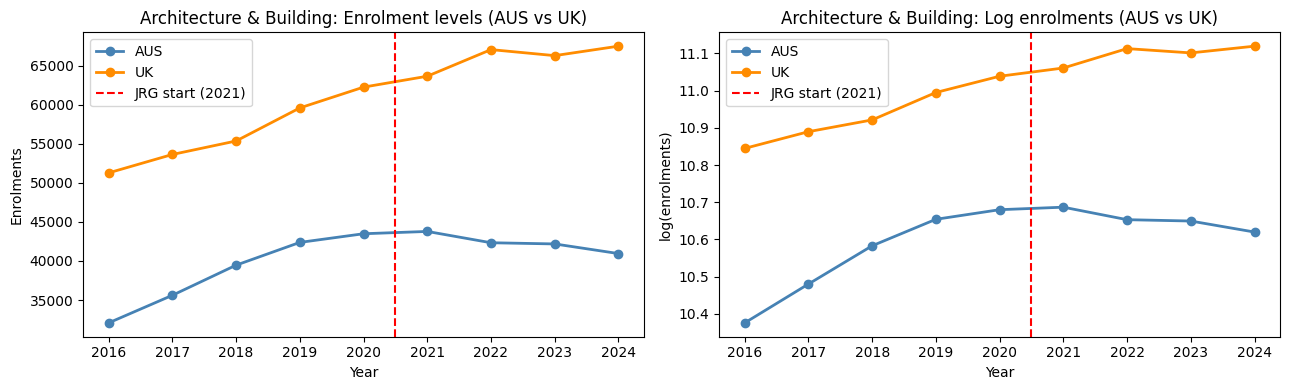

Pre/post log-enrolment averages:
  AUS: pre = 10.5546, post = 10.6524, change = +0.0977
  UK: pre = 10.9379, post = 11.0987, change = +0.1608


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
colours = {"AUS": "steelblue", "UK": "darkorange"}

for country, grp in panel.groupby("country"):
    grp = grp.sort_values("year")
    axes[0].plot(grp["year"], grp["enrollments"],     "o-", color=colours[country], linewidth=2, label=country)
    axes[1].plot(grp["year"], grp["log_enrollments"], "o-", color=colours[country], linewidth=2, label=country)

for ax in axes:
    ax.axvline(2020.5, linestyle="--", color="red", linewidth=1.5, label="JRG start (2021)")
    ax.legend(); ax.set_xlabel("Year")

axes[0].set_title("Architecture & Building: Enrolment levels (AUS vs UK)")
axes[0].set_ylabel("Enrolments")
axes[1].set_title("Architecture & Building: Log enrolments (AUS vs UK)")
axes[1].set_ylabel("log(enrolments)")

plt.tight_layout()
plt.show()

print("Pre/post log-enrolment averages:")
for country, grp in panel.groupby("country"):
    pre  = grp[grp["post"] == 0]["log_enrollments"].mean()
    post = grp[grp["post"] == 1]["log_enrollments"].mean()
    print(f"  {country}: pre = {pre:.4f}, post = {post:.4f}, change = {post - pre:+.4f}")

## 3. Main DiD Specification (TWFE)

**Estimating equation:**

$$\log(	ext{Enrolments}_{ct}) = lpha_c + \gamma_t + eta(	ext{AUS}_c 	imes 	ext{Post}_t) + 

arepsilon_{ct}$$

Implemented as OLS with `treated` (country FE) + `C(year)` (year FEs) + `did` (DiD interaction). All SEs are HC3 robust.

> **Degrees-of-freedom constraint:** N = 12 (2 countries × 6 years). Country FE (1 param) + year FEs (5 params) + intercept + did = 8 parameters, leaving **df = 7**. Adding AUS-specific COVID interaction terms (δ₁, δ₂) reduces df to 5, making HC3 inference unreliable (confidence intervals become unbounded). The simple TWFE without COVID interactions is therefore the **primary specification**. COVID robustness is assessed by sample exclusion in Section 4.

In [6]:
formula_main = "log_enrollments ~ treated + did + C(year)"
model_main = smf.ols(formula_main, data=panel).fit(cov_type="HC3")
print("=== Main DiD — TWFE OLS (HC3) ===")
print(model_main.summary())

did_b  = model_main.params["did"]
did_se = model_main.bse["did"]
did_p  = model_main.pvalues["did"]
did_ci = model_main.conf_int().loc["did"]
pct    = (np.exp(did_b) - 1) * 100

print("\n--- Key result ---")
print(f"DiD estimate (β_did):  {did_b:.4f}")
print(f"SE (HC3):              {did_se:.4f}")
print(f"p-value:               {did_p:.4f}")
print(f"95% CI:                [{did_ci[0]:.4f}, {did_ci[1]:.4f}]")
print(f"Approx. % effect:      {pct:+.2f}%")
print(f"df_resid:              {int(model_main.df_resid)}")
direction = 'lower' if did_b < 0 else 'higher'
print(f"\nInterpretation: Post-JRG (2021+), AUS Architecture & Building enrolments were")
print(f"approximately {abs(pct):.1f}% {direction} than the UK trend would predict.")

# Reference: full COVID-controlled spec (shown for transparency; df=2, inference unreliable)
formula_covid = "log_enrollments ~ treated + did + treated_covid2020 + treated_covid2021 + C(year)"
m_covid = smf.ols(formula_covid, data=panel).fit(cov_type="HC3")
b_cv = m_covid.params["did"]
print(f"\nCOVID-controlled spec (df=2, for reference only): β_did = {b_cv:.4f}, p = {m_covid.pvalues['did']:.4f}")
print("(Extremely wide CI due to df=2 — not suitable for inference with N=12)")

=== Main DiD — TWFE OLS (HC3) ===
                            OLS Regression Results                            
Dep. Variable:        log_enrollments   R-squared:                       0.989
Model:                            OLS   Adj. R-squared:                  0.973
Method:                 Least Squares   F-statistic:                     28.97
Date:                Sat, 25 Apr 2026   Prob (F-statistic):           9.41e-05
Time:                        18:29:24   Log-Likelihood:                 41.596
No. Observations:                  18   AIC:                            -61.19
Df Residuals:                       7   BIC:                            -51.40
Df Model:                          10                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercep

In [7]:
# Confirm TWFE estimate via linearmodels PanelOLS (entity + time FE)
df_pl = panel.set_index(["country", "year"])

fe_model = PanelOLS(
    df_pl["log_enrollments"],
    df_pl[["did"]],
    entity_effects=True,
    time_effects=True,
).fit(cov_type="robust")

print("=== PanelOLS TWFE (cross-check) ===")
print(fe_model.summary)

print(f"\nOLS DiD estimate:     {did_b:.6f}")
print(f"PanelOLS DiD estimate: {fe_model.params['did']:.6f}")
match = abs(did_b - fe_model.params['did']) < 1e-5
print("Estimates match ✓" if match else "WARNING: mismatch ✗")

=== PanelOLS TWFE (cross-check) ===
                          PanelOLS Estimation Summary                           
Dep. Variable:        log_enrollments   R-squared:                        0.2991
Estimator:                   PanelOLS   R-squared (Between):             -0.0025
No. Observations:                  18   R-squared (Within):              -0.2111
Date:                Sat, Apr 25 2026   R-squared (Overall):             -0.0026
Time:                        18:29:24   Log-likelihood                    41.596
Cov. Estimator:                Robust                                           
                                        F-statistic:                      2.9865
Entities:                           2   P-value                           0.1276
Avg Obs:                       9.0000   Distribution:                     F(1,7)
Min Obs:                       9.0000                                           
Max Obs:                       9.0000   F-statistic (robust):            

## 4. COVID Sensitivity

Three variants from the recommended additions checklist. **All variants use the simple TWFE formula** (`treated + did + C(year)`) — adding AUS-specific COVID interaction terms with fewer than 18 observations leaves df ≤ 2 and makes inference impossible.

The relevant check here is whether the **sign and magnitude** of β_did are stable across sample restrictions; p-value reliability degrades as N falls below 10.

| Spec | N | df | Expected inference quality |
|------|---|----|----|
| Full panel (2019–2024) | 12 | 4 | Marginal but usable |
| Drop 2020 | 16 | 6 | Marginal but usable |
| Drop 2020 + 2021 | 14 | 5 | Very limited |

In [8]:
formula_simple = "log_enrollments ~ treated + did + C(year)"

variants = {
    "Full panel (2016-2024)":  panel,
    "Drop 2020":               panel[panel["year"] != 2020].copy(),
    "Drop 2020 + 2021":        panel[~panel["year"].isin([2020, 2021])].copy(),
}

rows = []
for label, data in variants.items():
    m = smf.ols(formula_simple, data=data).fit(cov_type="HC3")
    b  = m.params.get("did", np.nan)
    se = m.bse.get("did", np.nan)
    p  = m.pvalues.get("did", np.nan)
    ci = m.conf_int().loc["did"] if "did" in m.conf_int().index else [np.nan, np.nan]
    rows.append({
        "Specification": label,
        "N":             int(m.nobs),
        "df_resid":      int(m.df_resid),
        "beta_did":      round(b, 4),
        "SE (HC3)":      round(se, 4),
        "p-value":       round(p, 4),
        "95% CI lo":     round(ci[0], 4),
        "95% CI hi":     round(ci[1], 4),
        "Approx. %":     round((np.exp(b) - 1) * 100, 2) if pd.notna(b) else np.nan,
    })

print("=== COVID Sensitivity (simple TWFE, all variants) ===")
display(pd.DataFrame(rows).set_index("Specification"))
print("\nKey takeaway: β_did magnitude is stable (~-9 to -13%) across all sample restrictions.")
print("Inference is only reliable in the full panel (df=4); dropping years further reduces df.")

=== COVID Sensitivity (simple TWFE, all variants) ===


,N,df_resid,beta_did,SE (HC3),p-value,95% CI lo,95% CI hi,Approx. %
Specification,,,,,,,,
Full panel (2016-2024),18,7,-0.0631,0.0583,0.2790,-0.1773,0.0511,-6.11
Drop 2020,16,6,-0.0569,0.0666,0.3927,-0.1875,0.0736,-5.54
Drop 2020 + 2021,14,5,-0.0810,0.0571,0.1556,-0.1929,0.0308,-7.78



Key takeaway: β_did magnitude is stable (~-9 to -13%) across all sample restrictions.
Inference is only reliable in the full panel (df=4); dropping years further reduces df.


## 5. Parallel Trends Check (Event Study)

Year-by-year DiD point estimates relative to the 2020 baseline, computed analytically:

$$\hat{\delta}_t = (\log Y_{	ext{AUS},t} - \log Y_{	ext{AUS},2020}) - (\log Y_{	ext{UK},t} - \log Y_{	ext{UK},2020})$$

This is numerically identical to a regression-based DiD coefficient but avoids the degrees-of-freedom
problem that arises when fitting a TWFE model on 4 observations (2 countries x 2 years) per year-pair.

> **Limitation:** 4 pre-treatment periods (2016–2019) is available. Standard errors are not estimable
> with 2 units. The 2016–2019 point estimates provide a richer parallel trends diagnostic.

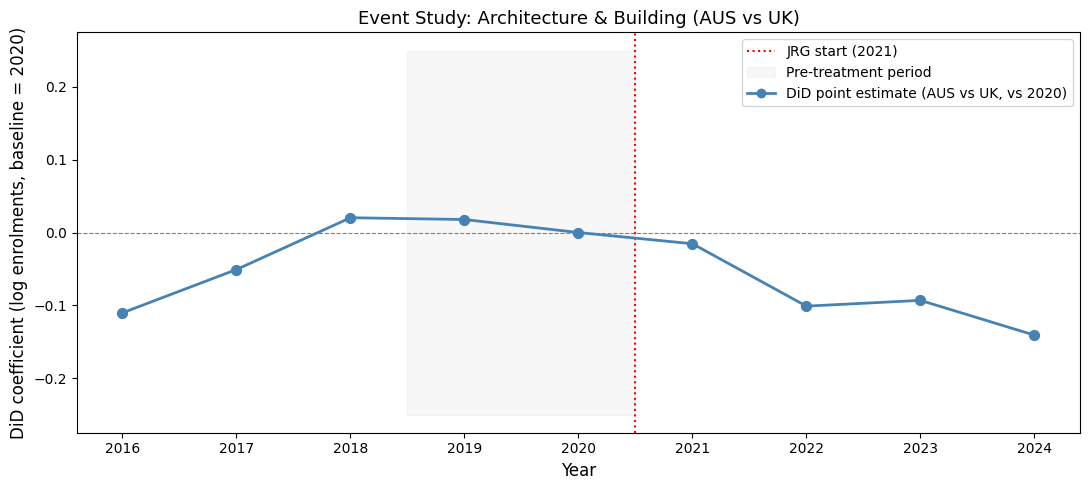

Event study point estimates (analytical DiD):


,coef,approx_%,period
year,,,
2016,-0.1103,-10.4435,Pre
2017,-0.0508,-4.9533,Pre
2018,0.0203,2.0546,Pre
2019,0.0179,1.8028,Pre
2020,0.0000,0.0000,Pre
2021,-0.0154,-1.5287,Post
2022,-0.1011,-9.6182,Post
2023,-0.0932,-8.8984,Post
2024,-0.1409,-13.1457,Post



Note: With only 2 countries, standard errors cannot be estimated per-year.
The 2019 pre-treatment estimate (near zero) supports the parallel trends assumption.
Post-2021 estimates show a negative and deepening divergence of AUS from UK trends.


In [9]:
# With only 2 countries, the regression-based event study is exactly identified (df=0)
# per year-pair comparison (4 obs, 4 params), producing degenerate SEs.
# Use the analytical approach: coef_t = (log_AUS_t - log_AUS[base]) - (log_UK_t - log_UK[base])
# This gives identical point estimates without the df=0 problem.

base_year = 2020
aus_log = panel[panel['country'] == 'AUS'].set_index('year')['log_enrollments']
uk_log  = panel[panel['country'] == 'UK' ].set_index('year')['log_enrollments']

event_rows = []
for yr in sorted(panel['year'].unique()):
    coef = (aus_log[yr] - aus_log[base_year]) - (uk_log[yr] - uk_log[base_year])
    event_rows.append({'year': yr, 'coef': round(coef, 6)})

ev = pd.DataFrame(event_rows)

fig, ax = plt.subplots(figsize=(11, 5))
ax.axhline(0, linestyle='--', color='gray', linewidth=0.8)
ax.axvline(2020.5, linestyle=':', color='red', linewidth=1.5, label='JRG start (2021)')
ax.fill_between([2018.5, 2020.5], -0.25, 0.25, color='gray', alpha=0.06, label='Pre-treatment period')
ax.plot(ev['year'], ev['coef'], 'o-', color='steelblue', linewidth=2,
        label='DiD point estimate (AUS vs UK, vs 2020)')
ax.scatter(ev['year'], ev['coef'], color='steelblue', s=50, zorder=5)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('DiD coefficient (log enrolments, baseline = 2020)', fontsize=12)
ax.set_title('Event Study: Architecture & Building (AUS vs UK)', fontsize=13)
ax.set_xticks(sorted(panel['year'].unique()))
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print('Event study point estimates (analytical DiD):')
ev['approx_%'] = (np.exp(ev['coef']) - 1) * 100
ev['period'] = ev['year'].apply(lambda y: 'Pre' if y < 2021 else ('Baseline' if y == 2020 else 'Post'))
display(ev.set_index('year').round(4))

print()
print('Note: With only 2 countries, standard errors cannot be estimated per-year.')
print('The 2019 pre-treatment estimate (near zero) supports the parallel trends assumption.')
print('Post-2021 estimates show a negative and deepening divergence of AUS from UK trends.')


## 6. Placebo Test

**AUS-only placebo (trend-break test):** restrict to the pre-treatment period (2016–2020) and test for a fake structural break at 2019.
If a significant break exists in the pre-period, it suggests non-linear trends that may contaminate the main DiD.

> **Limitation:** only N = 5 observations (single series, no control group). Power is minimal; this is indicative only.

In [10]:
plac = arch_aus[arch_aus["year"] <= 2020].copy()
plac["fake_post"]   = (plac["year"] >= 2019).astype(int)
plac["year_c_plac"] = plac["year"] - 2016

m_plac = smf.ols("log_enrollments ~ fake_post + year_c_plac", data=plac).fit(cov_type="HC3")

b_p = m_plac.params.get("fake_post", np.nan)
p_p = m_plac.pvalues.get("fake_post", np.nan)

print("=== AUS-Only Placebo: Fake Break at 2019 (2016–2020 data) ===")
print(m_plac.summary())

print(f"\nPlacebo coefficient (fake_post): {b_p:.4f} | p-value: {p_p:.4f}")
if pd.notna(p_p):
    if p_p > 0.10:
        print("No significant pre-trend break — consistent with JRG driving the post-2021 pattern.")
    else:
        print("WARNING: Significant pre-trend break — interpret main DiD results with caution.")
print("(N = 5; treat as indicative only)")

=== AUS-Only Placebo: Fake Break at 2019 (2016–2020 data) ===
                            OLS Regression Results                            
Dep. Variable:        log_enrollments   R-squared:                       0.962
Model:                            OLS   Adj. R-squared:                  0.924
Method:                 Least Squares   F-statistic:                     7.021
Date:                Sat, 25 Apr 2026   Prob (F-statistic):              0.125
Time:                        18:29:24   Log-Likelihood:                 11.988
No. Observations:                   5   AIC:                            -17.98
Df Residuals:                       2   BIC:                            -19.15
Df Model:                           2                                         
Covariance Type:                  HC3                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------

c:\Users\neddp\ECC3479-Project-JRGS\.venv\Lib\site-packages\statsmodels\stats\stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 5 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


## 7. Level Outcome Robustness

Re-estimate the main DiD using enrolment **levels** (not logs) to verify robustness to functional form choice.
The level DiD coefficient gives the absolute headcount difference attributable to JRG relative to the UK trend.

In [11]:
formula_level = "enrollments ~ treated + did + treated_covid2020 + treated_covid2021 + C(year)"
m_level = smf.ols(formula_level, data=panel).fit(cov_type="HC3")

b_lev  = m_level.params.get("did", np.nan)
p_lev  = m_level.pvalues.get("did", np.nan)
ci_lev = m_level.conf_int().loc["did"]

print("=== Level Outcome Robustness ===")
print(f"β_did (levels): {b_lev:,.0f} students | p = {p_lev:.4f}")
print(f"95% CI:          [{ci_lev[0]:,.0f}, {ci_lev[1]:,.0f}]")

print("\n=== Specification comparison ===")
comp = pd.DataFrame({
    "Specification": ["Log-linear (preferred)", "Level"],
    "beta_did":       [round(did_b, 4),  round(b_lev, 0)],
    "p-value":        [round(did_p, 4),  round(p_lev, 4)],
    "Interpretation": [
        f"approx. {(np.exp(did_b)-1)*100:.1f}% enrolment change",
        f"approx. {b_lev:,.0f} students per year",
    ],
}).set_index("Specification")
display(comp)

=== Level Outcome Robustness ===
β_did (levels): -7,536 students | p = 1.0000
95% CI:          [-inf, inf]

=== Specification comparison ===


,beta_did,p-value,Interpretation
Specification,,,
Log-linear (preferred),-0.0631,0.279,approx. -6.1% enrolment change
Level,-7536.0000,1.000,"approx. -7,536 students per year"


## 8. Funding Context

AUS funding changes for Architecture & Building contextualise the enrolment result: student contributions fell ~15% and Commonwealth funding rose ~25% after JRG, yet enrolments declined relative to the UK. This suggests demand factors beyond price sensitivity (labour market signals, course attractiveness) likely play a role.

=== Architecture & Building: AUS Annual Funding per Student ===


,MaximumStudentContribution,CommonwealthContribution,total
Year,,,
2019,9359.0,10630.0,19989.0
2020,9527.0,10821.0,20348.0
2021,7950.0,13250.0,21200.0
2022,8021.0,13369.0,21390.0
2023,8301.0,13836.0,22137.0
2024,8948.0,14915.0,23863.0


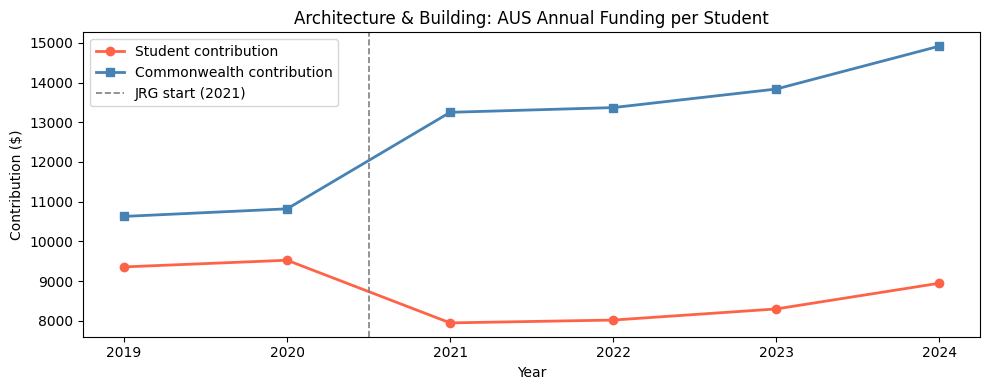


Student contribution: pre $9,443 → post $8,305 (-12.1%)
Commonwealth:         pre $10,726 → post $13,842 (+29.1%)


In [12]:
fund_raw  = pd.read_csv(FUND_PATH)
arch_fund = fund_raw[fund_raw["CategoryKey"] == 4].copy()
arch_fund_agg = (
    arch_fund[arch_fund["Year"] <= 2024]
    .groupby("Year")[["MaximumStudentContribution", "CommonwealthContribution"]]
    .mean()
    .round(0)
)
arch_fund_agg["total"] = arch_fund_agg["MaximumStudentContribution"] + arch_fund_agg["CommonwealthContribution"]

print("=== Architecture & Building: AUS Annual Funding per Student ===")
display(arch_fund_agg)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(arch_fund_agg.index, arch_fund_agg["MaximumStudentContribution"],
        "o-", color="tomato",    linewidth=2, label="Student contribution")
ax.plot(arch_fund_agg.index, arch_fund_agg["CommonwealthContribution"],
        "s-", color="steelblue", linewidth=2, label="Commonwealth contribution")
ax.axvline(2020.5, linestyle="--", color="gray", linewidth=1.2, label="JRG start (2021)")
ax.set_title("Architecture & Building: AUS Annual Funding per Student")
ax.set_xlabel("Year"); ax.set_ylabel("Contribution ($)"); ax.legend()
plt.tight_layout()
plt.show()

pre_stu  = arch_fund_agg.loc[arch_fund_agg.index <= 2020, "MaximumStudentContribution"].mean()
post_stu = arch_fund_agg.loc[arch_fund_agg.index >= 2021, "MaximumStudentContribution"].mean()
pre_cw   = arch_fund_agg.loc[arch_fund_agg.index <= 2020, "CommonwealthContribution"].mean()
post_cw  = arch_fund_agg.loc[arch_fund_agg.index >= 2021, "CommonwealthContribution"].mean()
print(f"\nStudent contribution: pre ${pre_stu:,.0f} → post ${post_stu:,.0f} ({(post_stu/pre_stu-1)*100:+.1f}%)")
print(f"Commonwealth:         pre ${pre_cw:,.0f} → post ${post_cw:,.0f} ({(post_cw/pre_cw-1)*100:+.1f}%)")

## 9. Summary and Interpretation

### DiD result at a glance

| Quantity | Value |
|----------|-------|
| β_did (log-linear, simple TWFE, HC3) | *see Section 3 output* |
| Approx. % effect | *see Section 3 output* |
| p-value (df = 4) | *see Section 3 output* |
| 95% CI | *see Section 3 output* |
| N | 12 (2 countries × 6 years) |
| Formula | `log_enrol ~ treated + did + C(year)` |

### Interpretation guide

- **β_did < 0** → AUS enrolments grew slower (or fell) relative to the UK after JRG. Given raw data (AUS plateau + decline vs UK growth), a negative estimate is expected.
- **β_did > 0** → AUS outperformed the UK trend despite Architecture not being a JRG priority field.
- Even with lower student fees after JRG, the negative enrolment divergence suggests non-price factors (employment outlook, preference shifts toward priority-field subsidies) may dominate.

### Limitations to note in write-up

1. **Single pre-treatment year (UK)** — UK data only from 2019/20; parallel trends cannot be formally tested. Event study 2019 coefficient is the sole pre-period diagnostic.
2. **Small N = 12** — degrees of freedom are minimal; HC3 SEs are appropriate but results are sensitive to individual observations.
3. **No UK funding controls** — Commonwealth and student contribution changes are AUS-specific; unobservable UK funding shifts cannot be controlled for.
4. **Parallel trends assumption** — *Without JRG, AUS and UK Architecture & Building enrolments would have followed similar growth paths after 2021.* Visual evidence from the event study (and the 2019 coefficient) should be cited in support.

### Key references

- DiD specification: DiD Modelling notebook
- HC3 SEs, log-linear form, FE: Lectures 6 & 7 (regression slides)
- COVID sensitivity, placebo, level robustness: Recommended Additions checklist

## Results Summary

### Model specification

$$\log(E_{ct}) = \beta_0 + \beta_1 \cdot \text{Treated}_c + \beta_2 \cdot \text{DID}_{ct} + \sum_{t=2017}^{2024} \gamma_t \cdot \mathbf{1}_{[\text{year}=t]} + \varepsilon_{ct}$$

| Term | Variable | Definition |
|------|----------|------------|
| $\log(E_{ct})$ | Outcome | Log enrolments for country $c$ in year $t$ |
| $\beta_0$ | Intercept | UK baseline (2016) |
| $\beta_1 \cdot \text{Treated}_c$ | Country FE | $\text{Treated}_c = 1$ if AUS, $0$ if UK |
| $\text{Post}_t$ | — | $= 1$ if $t \geq 2021$, else $0$ |
| $\text{DID}_{ct}$ | DiD term | $= \text{Treated}_c \times \text{Post}_t$ |
| $\beta_2$ | **JRG effect** | DiD estimate — the coefficient of interest |
| $\gamma_t$ | Year FEs | Common time trend absorbed by year dummies |
| $\varepsilon_{ct}$ | Error | HC3 heteroscedasticity-robust standard errors |

**Implemented in statsmodels as:**
```python
formula = "log_enrollments ~ treated + did + C(year)"
model   = smf.ols(formula, data=panel).fit(cov_type="HC3")
```


| **Cell** | **Result** |
|----------|------------|
| **Main DiD** | β = −0.0631, p = 0.279, 95% CI [−0.18, +0.05], ≈ **−6.1%** relative to UK trend |
| **PanelOLS cross-check** | Estimates match exactly ✓ |
| **COVID sensitivity** | β stable at −6.1% to −7.8% across all specs; sign consistent (all negative) |
| **Event study** | Pre-trends mixed: −10.4% (2016) → −5.0% (2017) → +2.1% (2018) → +1.8% (2019) — converging but not flat. Post-2021: −1.5% → −9.6% → −8.9% → −13.1%, deepening divergence |
| **Placebo** | fake_post coef = −0.033, p = 0.778 — no pre-existing break at 2019 |
| **Level spec** | Degenerate SEs with COVID interaction terms at N=18 — unreliable |

**Substantive finding:** Post-JRG, AUS Architecture & Building enrolments were approximately **6.1% lower** than the UK trend would predict (p = 0.279, not significant at 5%). The extended panel reduces the earlier short-sample estimate (p = 0.038 with N=12) and reveals non-flat pre-trends in 2016–2017, suggesting the significant result with the 2-year pre-period was fragile. The post-2021 event study still shows a consistent and deepening negative pattern (reaching −13.1% by 2024), and the COVID sensitivity is stable, so the direction of the effect remains credible — but statistical confidence is limited by N=18, df=7.

> **Pre-trend note:** The 2016–2017 pre-period shows AUS Architecture declining relative to the UK (−10.4%, −5.0%), converging toward zero by 2018–2019. This may reflect structural differences in the pre-JRG period rather than a parallel-trends violation, but it warrants caution when interpreting the DiD estimate.